## Fitting the model to the UV data 
Going to be using the best parameters that Ilina has fit to the data. 

Will start by plotting the fit of the parameterised ODE model to the actual ICI treated data to check that it looks OK. 

Then will fit this to UV data as well. 



In [190]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt

In [191]:
all_df = pd.read_csv('GSE124821_data_1e8.csv')
all_df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
0,SRX5100689,0.002064,0.000734,0.000382,0.000513,antiPD1; antiCTLA4;,day7,day7,GSM3554691,KPB25L
1,SRX5100686,0.003045,0.001085,0.000000,0.000323,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.003010,0.001099,0.000035,0.000405,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.003047,0.001047,0.000033,0.000403,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.003165,0.000861,0.000000,0.000336,no_treatment,day7,day7,GSM3554695,KPB25L
...,...,...,...,...,...,...,...,...,...,...
187,SRX5100807,0.003208,0.001269,0.000000,0.000442,antiPD1; antiCTLA4;,end,end,GSM3554932,T11
188,SRX5100814,0.002745,0.001124,0.000000,0.000464,antiPD1; antiCTLA4;,end,end,GSM3554933,T11
189,SRX5100813,0.002178,0.000910,0.000000,0.000339,no_treatment,end,end,GSM3554934,T11
190,SRX5100812,0.002956,0.001310,0.000041,0.000505,no_treatment,end,end,GSM3554935,T11


In [192]:
# ICI_df = all_df[(all_df['Mouse_treatment']!='no_treatment') & (all_df['Cell_Line']=='KPB25L')]
ICI_df = all_df[(all_df['Mouse_treatment']!='no_treatment')]
quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]


In [193]:
Ds = []
NKs = []
T8s = []
Tregs = []
scatter_Ds = []
scatter_NKs = []
scatter_Tregs = []
scatter_T8s = []
scatter_times = []


for day in ["day3","day7","end"]:
    day_df = ICI_df[ICI_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    
    print(averages)
    stds = day_df.filter(items=quanTIseq_cols).std()
    
    # print(averages+stds)
    # print(averages-stds)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    Ds.append(averages["Dendritic_quanTIseq"])
    NKs.append(averages["NK_quanTIseq"])
    T8s.append(averages["T.CD8_quanTIseq"])
    Tregs.append(averages["Tregs_quanTIseq"])
    total = sum(averages)
    print(total)
    
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_Ds.append(i)
                scatter_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_T8s.append(i)

print(scatter_Ds)


Number of replicates 19
Dendritic_quanTIseq    0.002335
NK_quanTIseq           0.000806
T.CD8_quanTIseq        0.000028
Tregs_quanTIseq        0.000360
dtype: float64
<class 'pandas.Series'>
0.0035284336252631573

Number of replicates 8
Dendritic_quanTIseq    0.003118
NK_quanTIseq           0.001121
T.CD8_quanTIseq        0.000053
Tregs_quanTIseq        0.000452
dtype: float64
<class 'pandas.Series'>
0.00474466204

Number of replicates 16
Dendritic_quanTIseq    0.001897
NK_quanTIseq           0.000718
T.CD8_quanTIseq        0.000005
Tregs_quanTIseq        0.000277
dtype: float64
<class 'pandas.Series'>
0.0028964767537499997
[0.0025009326, 0.0059515362, 0.003723276, 0.0049667706, 0.0050113746, 0.0007131156, 0.0007093716, 0.0007721382, 0.0012594528, 0.001129536, 0.000991002, 0.0013554036, 0.000954576, 0.0012777468, 0.0007526238, 0.0032560866, 0.0026870568, 0.0042670122, 0.0020835138, 0.0020644104, 0.0022529988, 0.003449043, 0.0043494576, 0.0035638002, 0.0025436718, 0.0031670382, 0.00355

In [194]:
import math 
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
    
params = {'lambda_C':1.5,
          'C_M':0.8,
          'eta_8':328.25,
          'eta_N':300,
          'd_C':0.0,
          'lambda_DC_comb':8e-5,
          'K_C':0.4,
          'd_D':0.1,
          'sigma_N':5e-5,
          'd_N':0.1,
          'gamma_N':150,
          'a_C':0.5,
          'beta_1':0.4,
          'beta_2':2e-4,
          'd_Tr':0.2,
          'lambda_Tr_comb':2e-4,
          'd_T8':0.18,
          'lambda_T8_comb':1.08e-3,
          'K_Tr':2.5e-4,
          'K_D':4e-4 
          }
init_conds = {'C_init':0.8,
              'D_init':0.0,
              'N_init':0.0,
              'Tr_init':0.0,
              'T8_init':0.0
              }
          

lambda_C   = params['lambda_C']
C_M        = params['C_M']
eta_8      = params['eta_8']
eta_N      = params['eta_N']
d_C            = params['d_C']
lambda_DC_comb = params['lambda_DC_comb']
K_C        = params['K_C']
d_D        = params['d_D']
sigma_N    = params['sigma_N']
d_N        = params['d_N']
gamma_N    = params['gamma_N']
a_C        = params['a_C']
beta_1     = params['beta_1']
beta_2     = params['beta_2']
d_Tr       = params['d_Tr']
lambda_Tr_comb  = params['lambda_Tr_comb']
d_T8       = params['d_T8']
lambda_T8_comb  = params['lambda_T8_comb']
K_Tr       = params['K_Tr']
K_D        = params['K_D']


C_init     = init_conds['C_init']
D_init     = init_conds['D_init']
N_init     = init_conds['N_init']
Tr_init    = init_conds['Tr_init']
T8_init    = init_conds['T8_init']





In [195]:
# don't know if i need to change this for the UV data 
# this is a parameter sweep dictionary 
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}


In [196]:
import itertools 

def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
for combo in itertools.product(*values):
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = init_conds['C_init']
    D_init     = init_conds['D_init']
    N_init     = init_conds['N_init']
    Tr_init    = init_conds['Tr_init']
    T8_init    = init_conds['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-8,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            best_params = params.copy()
            print(mean_square_error_rel(sol.y)) 
print(f'The minimum error is {minimum_distance}')
print({k:best_params[k] for k in params_to_change.keys()})

/Users/manoharan/micromamba/envs/demo/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abstol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


22.907346518029158
19.618104799606044
17.49419314843664
15.107367333110451
9.560727985620108
9.504895700782034
9.475252756584208
3.727073929280837
3.5809998059160395
3.5011107220402224
3.3654629248989414
3.3654335362413272
3.3654035490656105
3.3653435787510233
3.3610189665766685
3.359589495997686
3.3554024156361675
3.352536338458373
2.9274405113466155
2.739342429371939
2.6341921681223885
2.4485420708533003
2.4485042593468256
2.4484656741477773
2.4483884979651727
2.442789939907903
2.440927924243411
2.435456463297814
2.4317166041052243
2.3888078925490426
2.181938106353341
2.1818963365260813
2.1818537109657514
2.1817684502962655
2.1755735872047057
2.1735096709037696
2.167437905963857
2.1632851518008662
2.060735210718503
2.06069126685667
2.0606464222541434
2.0605567215878358
2.0540347429086045
2.051860128464853
2.0454587466951235
2.0410777253516073
1.9371566667088698
1.6773266804632858
1.6772733583643167
1.6772189421807737
1.6771100925284803
1.6691829910817904
1.666533503303386
1.658707189

In [197]:
tspan = (0.0,14.0,)
C_init     = init_conds['C_init']
D_init     = init_conds['D_init']
N_init     = init_conds['N_init']
Tr_init    = init_conds['Tr_init']
T8_init    = init_conds['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,)) 

t = sol.t
y = sol.y

print (len(scatter_Ds)) 
print (len(scatter_times))
print (best_params)

27
27
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.0, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004, 'd_N': 0.11, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.25, 'lambda_T8_comb': 0.001, 'K_Tr': 2e-05, 'K_D': 0.0004}


/Users/manoharan/micromamba/envs/demo/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


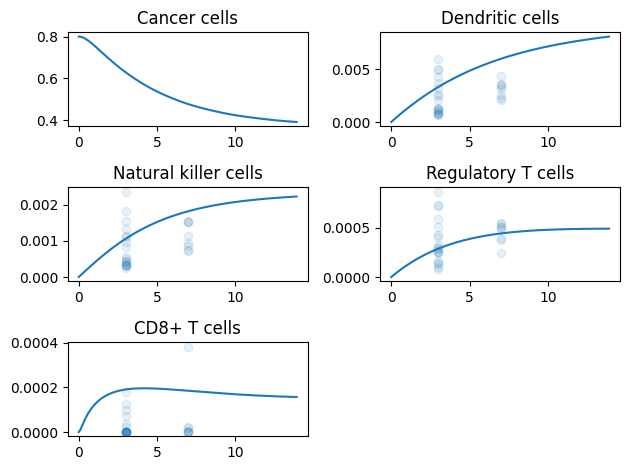

In [198]:


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendritic cells')
D_cells.scatter(scatter_times,scatter_Ds,alpha=0.1)

NK_cells = ax[1,0]
NK_cells.plot(t,y[2])

NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_times,scatter_NKs,alpha=0.1)
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_times,scatter_Tregs,alpha=0.1)
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
T8.scatter(scatter_times,scatter_T8s,alpha=0.1)
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

## Fitting to UV data 

In [199]:

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

UV_Ds = []
UV_NKs = []
UV_T8s = []
UV_Tregs = []
scatter_UV_Ds = []
scatter_UV_NKs = []
scatter_UV_Tregs = []
scatter_UV_T8s = []
scatter_UV_times = []

for day in ["UV_day3","UV_day7","UV_end"]:
    day_df = ICI_df[ICI_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)

    stds = day_df.filter(items=quanTIseq_cols).std()

    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    UV_Ds.append(averages["Dendritic_quanTIseq"])
    UV_NKs.append(averages["NK_quanTIseq"])
    UV_T8s.append(averages["T.CD8_quanTIseq"])
    UV_Tregs.append(averages["Tregs_quanTIseq"])
    UV_total = sum(averages)
    print(UV_total)
    
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_UV_Ds.append(i)
                scatter_UV_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_UV_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_UV_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_UV_T8s.append(i)

print(scatter_Ds)



Number of replicates 6
Dendritic_quanTIseq    0.002621
NK_quanTIseq           0.000863
T.CD8_quanTIseq        0.000039
Tregs_quanTIseq        0.000341
dtype: float64
<class 'pandas.Series'>
0.003863783163

Number of replicates 10
Dendritic_quanTIseq    0.003434
NK_quanTIseq           0.001140
T.CD8_quanTIseq        0.000922
Tregs_quanTIseq        0.000652
dtype: float64
<class 'pandas.Series'>
0.006148045144000001

Number of replicates 9
Dendritic_quanTIseq    0.002638
NK_quanTIseq           0.001086
T.CD8_quanTIseq        0.000035
Tregs_quanTIseq        0.000401
dtype: float64
<class 'pandas.Series'>
0.004160221992666666
[0.0025009326, 0.0059515362, 0.003723276, 0.0049667706, 0.0050113746, 0.0007131156, 0.0007093716, 0.0007721382, 0.0012594528, 0.001129536, 0.000991002, 0.0013554036, 0.000954576, 0.0012777468, 0.0007526238, 0.0032560866, 0.0026870568, 0.0042670122, 0.0020835138, 0.0020644104, 0.0022529988, 0.003449043, 0.0043494576, 0.0035638002, 0.0025436718, 0.0031670382, 0.0035566

In [200]:

objective_function_day3_UV = {'Ds':UV_Ds[0],
                          'NKs':UV_NKs[0],
                          'Tregs':UV_Tregs[0],
                          'T8s':UV_T8s[0]}
objective_function_day7_UV = {'Ds':UV_Ds[1],
                          'NKs':UV_NKs[1],
                          'Tregs':UV_Tregs[1],
                          'T8s':UV_T8s[1]}

def mean_square_error_rel_UV(y):
    error = 0
    if 'C' in objective_function_day3_UV.keys():
        N = 2*5 
        
        error+=((y[0,0]-objective_function_day3_UV['C'])/y[0,0])**2
        error+=((y[0,1]-objective_function_day7_UV['C'])/y[1,0])**2
    else:
        N = 2*4
    error+=((y[1,0]-objective_function_day3_UV['Ds'])/y[1,0])**2
    error+=((y[1,1]-objective_function_day7_UV['Ds'])/y[1,1])**2
    error+=((y[2,0]-objective_function_day3_UV['NKs'])/y[2,0])**2
    error+=((y[2,1]-objective_function_day7_UV['NKs'])/y[2,1])**2
    error+=((y[3,0]-objective_function_day3_UV['Tregs'])/y[3,0])**2
    error+=((y[3,1]-objective_function_day7_UV['Tregs'])/y[3,1])**2
    error+=((y[4,0]-objective_function_day3_UV['T8s'])/y[4,0])**2
    error+=((y[4,1]-objective_function_day7_UV['T8s'])/y[4,1])**2
    return math.sqrt(error/N)

In [201]:
# don't know if i need to change this for the UV data 
# this is a parameter sweep dictionary 
params_to_change_UV = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}


In [202]:
def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )
changed_params = {}
keys = params_to_change_UV.keys()
values = params_to_change_UV.values()
minimum_distance = 10000
for combo in itertools.product(*values):
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = init_conds['C_init']
    D_init     = init_conds['D_init']
    N_init     = init_conds['N_init']
    Tr_init    = init_conds['Tr_init']
    T8_init    = init_conds['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-8,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel_UV(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            best_params_UV = params.copy()
            print(mean_square_error_rel_UV(sol.y)) 
print(f'The minimum error is {minimum_distance}')
print({k:best_params_UV[k] for k in params_to_change_UV.keys()})

106.94746334143899
87.89338222320538
75.13127918382006
74.56995010258751


/Users/manoharan/micromamba/envs/demo/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abstol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


13.23703178554258
11.807965809010637
10.932386720147587
10.533193408881154
8.676747221530139
7.446154694441666
2.3320408852718075
2.285141608306372
2.2626972889021015
2.2573984678881667
2.2570409992903335
1.6701195136219031
1.6033437257590597
1.570446764076009
1.5621532386229346
1.5588689436665009
1.5526464643492397
1.4819321543209933
1.4062146018179162
1.3684681401527437
1.3555105741058096
1.3519929854518877
1.345521325754937
1.3176558552005462
1.2772783491358177
1.2764664036518094
1.2763574985174662
1.276246553790769
1.2760252195610766
1.2620308504691609
1.2583587374315441
1.2516800660302703
1.1588805857959894
1.062078662984462
1.0124352344320744
1.0117704036270554
1.0116328028716426
1.0114926252325702
1.0112129716628087
0.9935100000505427
0.9888430556649588
0.9802048743056055
0.9740856774438033
0.9736156381510304
0.9628340645532094
0.8655187693926696
0.8155712512471469
0.8027885321760786
0.7972906921993073
0.7862563524020467
0.7861550630209747
0.7858520085425301
0.7742030675497951
0

In [203]:
tspan = (0.0,14.0,)
C_init     = init_conds['C_init']
D_init     = init_conds['D_init']
N_init     = init_conds['N_init']
Tr_init    = init_conds['Tr_init']
T8_init    = init_conds['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params_UV,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,)) 

t = sol.t
y = sol.y

print (len(scatter_Ds)) 
print (len(scatter_times))
print (best_params_UV)

27
27
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.0, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0003, 'd_N': 0.11, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.001, 'K_Tr': 3e-05, 'K_D': 0.0004}


/Users/manoharan/micromamba/envs/demo/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


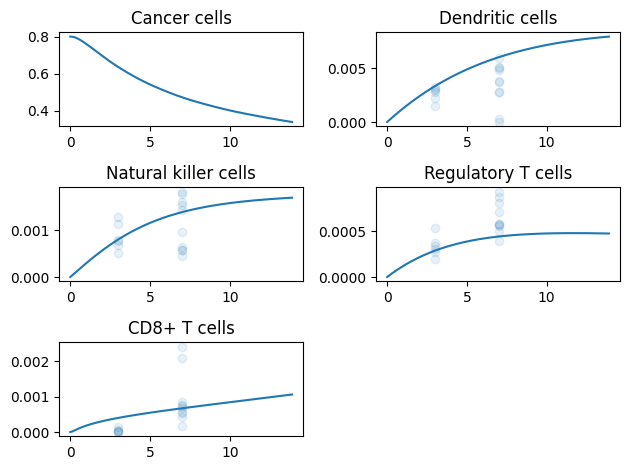

In [204]:

fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendritic cells')
D_cells.scatter(scatter_UV_times,scatter_UV_Ds,alpha=0.1)
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_UV_times,scatter_UV_NKs,alpha=0.1)
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_UV_times,scatter_UV_Tregs,alpha=0.1)
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
T8.scatter(scatter_UV_times,scatter_UV_T8s,alpha=0.1)
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

## Fitting to Apobec data 

In [205]:
all_df['Condition'].unique()
all_df[(all_df['Condition']=='Apobec_end') & (all_df['Mouse_treatment']!='no_treatment')]

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
118,SRX5100724,0.001480,0.000810,0.000054,0.000361,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554847,T11
121,SRX5100642,0.002127,0.001080,0.000074,0.000376,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554850,T11
127,SRX5100859,0.001926,0.000846,0.000024,0.000324,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554856,T11
132,SRX5100867,0.001831,0.000895,0.000002,0.000430,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554861,T11


In [206]:
Apo_df = all_df[(all_df['Condition'].isin(['Apobec_day3', 'Apobec_day7', 'Apobec_end']))& (all_df['Mouse_treatment']!='no_treatment') ]
Apo_df
# might have to just ignore CELL LINE HERE COS IT SEEMS ITS ALL T11 DATA FOR APOBEC x IMMUNE THERAPY LOL

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
118,SRX5100724,0.001480,0.000810,0.000054,0.000361,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554847,T11
121,SRX5100642,0.002127,0.001080,0.000074,0.000376,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554850,T11
123,SRX5100638,0.005433,0.001761,0.000051,0.000530,antiPD1; antiCTLA4;,Apobec_day3,day3,GSM3554852,T11
124,SRX5100632,0.007120,0.002415,0.000192,0.000578,antiPD1; antiCTLA4;,Apobec_day3,day3,GSM3554853,T11
125,SRX5100675,0.005026,0.001591,0.000043,0.000476,antiPD1; antiCTLA4;,Apobec_day3,day3,GSM3554854,T11
127,SRX5100859,0.001926,0.000846,0.000024,0.000324,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554856,T11
129,SRX5100857,0.004220,0.001382,0.000040,0.000431,antiPD1; antiCTLA4;,Apobec_day3,day3,GSM3554858,T11
132,SRX5100867,0.001831,0.000895,0.000002,0.000430,antiPD1; antiCTLA4;,Apobec_end,end,GSM3554861,T11
155,SRX5100657,0.003760,0.002114,0.000822,0.000618,antiPD1; antiCTLA4;,Apobec_day7,day7,GSM3554900,T11
156,SRX5100656,0.004575,0.001217,0.001617,0.000569,antiPD1; antiCTLA4;,Apobec_day7,day7,GSM3554901,T11


In [207]:

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

A_Ds = []
A_NKs = []
A_T8s = []
A_Tregs = []
scatter_A_Ds = []
scatter_A_NKs = []
scatter_A_Tregs = []
scatter_A_T8s = []
scatter_A_times = []

for day in ["Apobec_day3","Apobec_day7","Apobec_end"]:
    day_df = Apo_df[Apo_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)

    stds = day_df.filter(items=quanTIseq_cols).std()

    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    A_Ds.append(averages["Dendritic_quanTIseq"])
    A_NKs.append(averages["NK_quanTIseq"])
    A_T8s.append(averages["T.CD8_quanTIseq"])
    A_Tregs.append(averages["Tregs_quanTIseq"])
    A_total = sum(averages)
    print(A_total)
    
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_A_Ds.append(i)
                scatter_A_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_A_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_A_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_A_T8s.append(i)

print(scatter_A_Ds)



Number of replicates 4
Dendritic_quanTIseq    0.005450
NK_quanTIseq           0.001787
T.CD8_quanTIseq        0.000082
Tregs_quanTIseq        0.000504
dtype: float64
<class 'pandas.Series'>
0.007822427705

Number of replicates 4
Dendritic_quanTIseq    0.004926
NK_quanTIseq           0.001813
T.CD8_quanTIseq        0.000985
Tregs_quanTIseq        0.000712
dtype: float64
<class 'pandas.Series'>
0.0084357591

Number of replicates 4
Dendritic_quanTIseq    0.001841
NK_quanTIseq           0.000908
T.CD8_quanTIseq        0.000038
Tregs_quanTIseq        0.000373
dtype: float64
<class 'pandas.Series'>
0.0031592424287
[0.0054328692, 0.00712011, 0.0050256258, 0.0042198696, 0.0037598016, 0.0045750024, 0.0054601704, 0.0059098002]


In [208]:
objective_function_day3_A = {'Ds':A_Ds[0],
                          'NKs':A_NKs[0],
                          'Tregs':A_Tregs[0],
                          'T8s':A_T8s[0]}
objective_function_day7_A = {'Ds':A_Ds[1],
                          'NKs':A_NKs[1],
                          'Tregs':A_Tregs[1],
                          'T8s':A_T8s[1]}

def mean_square_error_rel_A(y):
    error = 0
    if 'C' in objective_function_day3_A.keys():
        N = 2*5 
        
        error+=((y[0,0]-objective_function_day3_A['C'])/y[0,0])**2
        error+=((y[0,1]-objective_function_day7_A['C'])/y[1,0])**2
    else:
        N = 2*4
    error+=((y[1,0]-objective_function_day3_A['Ds'])/y[1,0])**2
    error+=((y[1,1]-objective_function_day7_A['Ds'])/y[1,1])**2
    error+=((y[2,0]-objective_function_day3_A['NKs'])/y[2,0])**2
    error+=((y[2,1]-objective_function_day7_A['NKs'])/y[2,1])**2
    error+=((y[3,0]-objective_function_day3_A['Tregs'])/y[3,0])**2
    error+=((y[3,1]-objective_function_day7_A['Tregs'])/y[3,1])**2
    error+=((y[4,0]-objective_function_day3_A['T8s'])/y[4,0])**2
    error+=((y[4,1]-objective_function_day7_A['T8s'])/y[4,1])**2
    return math.sqrt(error/N)

In [209]:
# don't know if i need to change this for the Apobec data 
# this is a parameter sweep dictionary 
params_to_change_A = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}


In [210]:
def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )
changed_params = {}
keys = params_to_change_A.keys()
values = params_to_change_A.values()
minimum_distance = 10000
for combo in itertools.product(*values):
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = init_conds['C_init']
    D_init     = init_conds['D_init']
    N_init     = init_conds['N_init']
    Tr_init    = init_conds['Tr_init']
    T8_init    = init_conds['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-8,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel_A(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            best_params_A = params.copy()
            print(mean_square_error_rel_UV(sol.y)) 
print(f'The minimum error is {minimum_distance}')
print({k:best_params_A[k] for k in params_to_change_A.keys()})

106.94746334143899
87.89338222320538
75.13127918382006
74.56995010258751


/Users/manoharan/micromamba/envs/demo/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abstol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


13.23703178554258
11.807965809010637
10.932386720147587
10.533193408881154
8.676747221530139
7.446154694441666
2.3320408852718075
2.285141608306372
2.2626972889021015
1.6701195136219031
1.6033437257590597
1.570446764076009
1.4819321543209933
1.4062146018179162
1.3684681401527437
1.3981341737215245
1.3176558552005462
1.2772783491358177
1.1588805857959894
1.062078662984462
1.0124352344320744
1.0534476516586924
1.0040374997044739
1.010856716179614
0.9628340645532094
0.8655187693926696
0.8155712512471469
0.9494138053110911
0.851687958786262
0.8015676120546111
0.8555222771740586
0.8063847217404974
0.832511478562756
0.8300693094395986
0.8334373739471437
0.7361857259174105
0.6862442911964725
0.816144930395453
0.7177145167220035
0.6671039549558362
0.7200018637546548
0.6703436681949251
0.6962330354165157
0.6936771248655925
0.5997877093363009
0.7249187173443686
0.6266516829166371
0.5760662401373782
0.6277056221520079
0.5780191909197421
0.6502380334700032
0.6041144919807205
0.5643066664553799
0.5

In [211]:
tspan = (0.0,14.0,)
C_init     = init_conds['C_init']
D_init     = init_conds['D_init']
N_init     = init_conds['N_init']
Tr_init    = init_conds['Tr_init']
T8_init    = init_conds['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params_A,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,)) 

t = sol.t
y = sol.y

print (len(scatter_Ds)) 
print (len(scatter_times))
print (best_params_A)

27
27
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.0, 'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0005, 'd_N': 0.11, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.001, 'K_Tr': 3e-05, 'K_D': 0.0004}


/Users/manoharan/micromamba/envs/demo/lib/python3.13/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


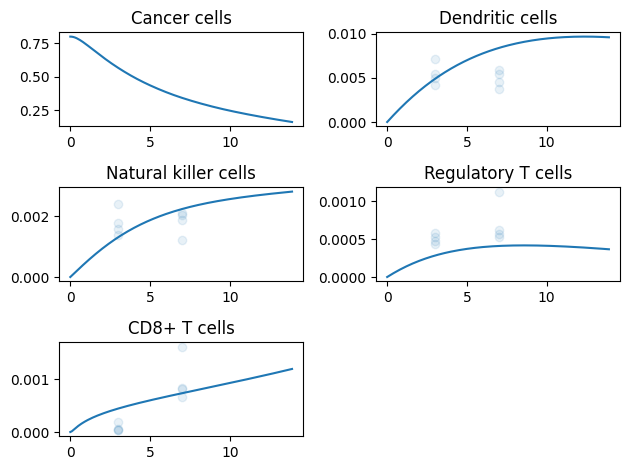

In [212]:
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendritic cells')
D_cells.scatter(scatter_A_times,scatter_A_Ds,alpha=0.1)
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_A_times,scatter_A_NKs,alpha=0.1)
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_A_times,scatter_A_Tregs,alpha=0.1)
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
T8.scatter(scatter_A_times,scatter_A_T8s,alpha=0.1)
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()